<a href="https://colab.research.google.com/github/ng-quys/DeepLearning/blob/main/buoi_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Bước 1 Scaler dữ liệu (dọn dẹp NaN và chữ)

Using Colab cache for faster access to the 'vietnam-housing-dataset-2024' dataset.
Path to dataset files: /kaggle/input/vietnam-housing-dataset-2024
Đang đọc file: /kaggle/input/vietnam-housing-dataset-2024/vietnam_housing_dataset.csv

--- Bản xem trước dữ liệu thô ban đầu ---


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.6
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.5
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.9




=== BƯỚC 1: LÀM SẠCH DỮ LIỆU TỰ ĐỘNG ===

--- [XEM THỬ DỮ LIỆU] 5 dòng đầu sau khi dọn chữ và điền NaN ---


,Area,Price,Bedrooms,Bathrooms,Floors
0,84.0,8.60,3.0,3.0,4.0
1,60.0,7.50,3.0,3.0,5.0
2,90.0,8.90,3.0,3.0,5.0
3,54.0,5.35,2.0,3.0,2.0
4,92.0,6.90,4.0,4.0,2.0



--- [THỐNG KÊ MÔ TẢ] Dữ liệu tổng quan trước khi lọc Outliers ---


,Area,Price,Bedrooms,Bathrooms,Floors
count,30229.000000,30229.000000,30229.000000,30229.000000,30229.000000
mean,68.498741,5.872078,3.423765,3.265672,3.361507
std,48.069835,2.211877,1.207520,1.234208,1.254256
min,3.100000,1.000000,1.000000,1.000000,1.000000
25%,40.000000,4.200000,3.000000,3.000000,2.000000
50%,56.000000,5.900000,3.000000,3.000000,3.000000
75%,80.000000,7.500000,4.000000,4.000000,4.000000
max,595.000000,11.500000,9.000000,9.000000,10.000000



--- [BIỂU ĐỒ] Đang vẽ Boxplot để soi dị biệt (Outliers)... ---


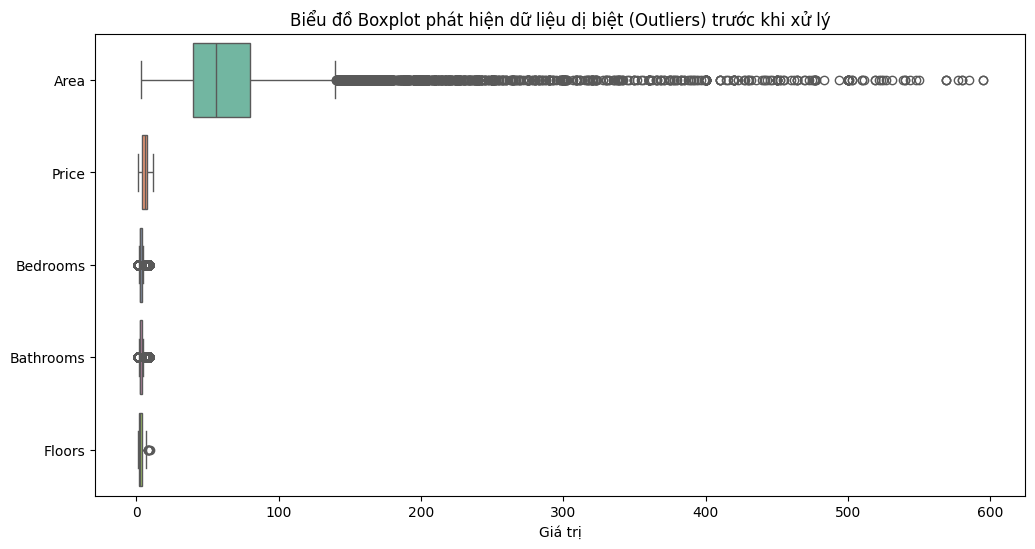


--- [HOÀN THÀNH] Dữ liệu SAU KHI ĐÃ LỌC bỏ tin ảo/outliers số tầng: ---


,Area,Price,Bedrooms,Bathrooms,Floors
count,30229.000000,30229.000000,30229.000000,30229.000000,30229.000000
mean,68.498741,5.872078,3.423765,3.265672,3.361507
std,48.069835,2.211877,1.207520,1.234208,1.254256
min,3.100000,1.000000,1.000000,1.000000,1.000000
25%,40.000000,4.200000,3.000000,3.000000,2.000000
50%,56.000000,5.900000,3.000000,3.000000,3.000000
75%,80.000000,7.500000,4.000000,4.000000,4.000000
max,595.000000,11.500000,9.000000,9.000000,10.000000


In [23]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Download phiên bản mới nhất của dataset từ Kaggle
path = kagglehub.dataset_download("nguyentiennhan/vietnam-housing-dataset-2024")
print("Path to dataset files:", path)

# 2. Tự động tìm file .csv trong thư mục vừa tải về và đọc vào DataFrame
files = [f for f in os.listdir(path) if f.endswith('.csv')]
if len(files) == 0:
    print("Không tìm thấy file CSV nào trong thư mục tải về!")
else:
    csv_file_path = os.path.join(path, files[0])
    print(f"Đang đọc file: {csv_file_path}")
    df = pd.read_csv(csv_file_path)

print("\n--- Bản xem trước dữ liệu thô ban đầu ---")
display(df.head(3))
print("\n" + "="*50 + "\n")


print("=== BƯỚC 1: LÀM SẠCH DỮ LIỆU TỰ ĐỘNG ===")
df.columns = df.columns.str.strip() #strip chuyển in hoa về in thường

# 1.1 Xử lý cột Diện tích (Area)
if 'Area' in df.columns and df['Area'].dtype == 'O': # O viết tắt của Object/String
    df['Area'] = df['Area'].astype(str).str.replace(' m2', '', regex=False).str.replace('.', '', regex=False)
    df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

# 1.2 Xử lý cột Giá (Price)
if 'Price' in df.columns:
    df = df[df['Price'] != 'Thỏa thuận']
    if df['Price'].dtype == 'O':
        df['Price'] = df['Price'].astype(str).str.replace(' tỷ', '', regex=False).str.strip()
        df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# 1.3 Xử lý dữ liệu trống (Missing values - NaN)
cols_to_fill = ['Area', 'Price', 'Bedrooms', 'Bathrooms', 'Floors']
for col in cols_to_fill:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# === ĐÂY RỒI: THÊM KIỂM TRA DỮ LIỆU VÀ VẼ BOXPLOT TRƯỚC KHI LỌC OUTLIERS ===
existing_numerical_cols = [c for c in cols_to_fill if c in df.columns]

print("\n--- [XEM THỬ DỮ LIỆU] 5 dòng đầu sau khi dọn chữ và điền NaN ---")
display(df[existing_numerical_cols].head())

print("\n--- [THỐNG KÊ MÔ TẢ] Dữ liệu tổng quan trước khi lọc Outliers ---")
display(df[existing_numerical_cols].describe())

print("\n--- [BIỂU ĐỒ] Đang vẽ Boxplot để soi dị biệt (Outliers)... ---")
plt.figure(figsize=(12, 6))
# Vẽ Boxplot cho tất cả các cột số để thấy các điểm chấm chấm (outliers) bay lơ lửng bên ngoài
sns.boxplot(data=df[existing_numerical_cols], orient="h", palette="Set2")
plt.title("Biểu đồ Boxplot phát hiện dữ liệu dị biệt (Outliers) trước khi xử lý")
plt.xlabel("Giá trị")
plt.show()
# =========================================================================

# 1.4 Loại bỏ biến dị cực đoan (Outliers): Ví dụ nhà > 20 tầng thường là chung cư hoặc nhập lỗi
if 'Floors' in df.columns:
    df = df[df['Floors'] <= 20]

print("\n--- [HOÀN THÀNH] Dữ liệu SAU KHI ĐÃ LỌC bỏ tin ảo/outliers số tầng: ---")
display(df[existing_numerical_cols].describe())

## Bước 2: Chia dữ liệu thô  thành 2 phần: Train set và Test set (ví dụ tỷ lệ 80/20) và trainform

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("=== BƯỚC 2: CHIA TRAIN - TEST (TRƯỚC KHI SCALE) ===")

# Giả sử bài toán là dùng các đặc trưng để dự đoán GIÁ NHÀ (Price)
X = df[existing_numerical_cols].drop(columns=['Price'])
y = df['Price']

# Tiến hành chia tập dữ liệu theo tỷ lệ 80% Train / 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Kích thước tập Train thô: {X_train.shape}")
print(f"Kích thước tập Test thô: {X_test.shape}\n")

# === ĐÂY RỒI: THÊM LỆNH XEM DATA THÔ TRƯỚC KHI CHUẨN HÓA ===
print("▶️ [XEM TRƯỚC] 5 dòng đầu của tập TRAIN THÔ (Dữ liệu gốc ban đầu):")
display(X_train.head())

print("\n▶️ [XEM TRƯỚC] 5 dòng đầu của tập TEST THÔ (Dữ liệu gốc ban đầu):")
display(X_test.head())
print("\n" + "="*50 + "\n")
# =========================================================


print("=== BƯỚC 3: TIẾN HÀNH CHUẨN HÓA MAX-MIN ĐÚNG QUY TRÌNH ===")
scaler = MinMaxScaler()

# 3.1 Vừa tính Min/Max vừa scale trực tiếp trên tập TRAIN
# fit dùng để tính min/max và transform dùng để ép về [0 -> 1]
X_train_scaled = scaler.fit_transform(X_train)

# 3.2 CHỈ transform (áp dụng Min/Max cũ của tập Train) lên tập TEST để tránh rò rỉ dữ liệu
# không dùng lại fit vì sẽ dùng lại kết quả của tập train (transform)
X_test_scaled = scaler.transform(X_test)

# Chuyển thành DataFrame để hiển thị trên Colab nhìn cho đẹp
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Kết quả 5 dòng đầu của tập TRAIN sau khi scale:")
display(X_train_scaled_df.head())

print("\nKết quả 5 dòng đầu của tập TEST sau khi áp thước đo từ tập Train:")
display(X_test_scaled_df.head())

=== BƯỚC 2: CHIA TRAIN - TEST (TRƯỚC KHI SCALE) ===
Kích thước tập Train thô: (24183, 4)
Kích thước tập Test thô: (6046, 4)

▶️ [XEM TRƯỚC] 5 dòng đầu của tập TRAIN THÔ (Dữ liệu gốc ban đầu):


,Area,Bedrooms,Bathrooms,Floors
20678,51.0,4.0,5.0,6.0
7508,160.0,4.0,5.0,3.0
25761,33.0,3.0,3.0,4.0
1611,100.0,3.0,3.0,3.0
13078,51.0,2.0,2.0,3.0



▶️ [XEM TRƯỚC] 5 dòng đầu của tập TEST THÔ (Dữ liệu gốc ban đầu):


,Area,Bedrooms,Bathrooms,Floors
23170,82.0,3.0,3.0,2.0
28362,70.0,6.0,6.0,4.0
19706,38.0,3.0,3.0,3.0
3594,50.0,5.0,4.0,4.0
17626,64.0,4.0,4.0,3.0




=== BƯỚC 3: TIẾN HÀNH CHUẨN HÓA MAX-MIN ĐÚNG QUY TRÌNH ===
Kết quả 5 dòng đầu của tập TRAIN sau khi scale:


,Area,Bedrooms,Bathrooms,Floors
0,0.080926,0.375,0.500,0.555556
1,0.265079,0.375,0.500,0.222222
2,0.050515,0.250,0.250,0.333333
3,0.163710,0.250,0.250,0.222222
4,0.080926,0.125,0.125,0.222222



Kết quả 5 dòng đầu của tập TEST sau khi áp thước đo từ tập Train:


,Area,Bedrooms,Bathrooms,Floors
0,0.133300,0.250,0.250,0.111111
1,0.113026,0.625,0.625,0.333333
2,0.058963,0.250,0.250,0.222222
3,0.079236,0.500,0.375,0.333333
4,0.102889,0.375,0.375,0.222222


## Bước 4  Dựng một mô hình Linear Regression (Hồi quy tuyến tính) đa biến đơn giản bằng Python thuần và thuật toán Gradient Descent để tìm ra bộ trọng số ($w$) tối ưu cho bài toán dự đoán giá nhà Việt Nam.

In [25]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

print("=== BƯỚC 4: TỰ DỰNG LINEAR REGRESSION & GRADIENT DESCENT ===")

# --- 4.1 Chuẩn bị dữ liệu ---
# Thêm cột số 1 vào đầu ma trận X để tính toán hệ số tự do (bias b)
X_b_train = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_b_test = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Chuẩn hóa riêng cột Price (y) về đoạn [0, 1] để huấn luyện
y_scaler = MinMaxScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))


# --- 4.2 Định nghĩa các siêu tham số (Hyperparameters) ---
learning_rate = 0.1    # Tăng lên 0.1 một chút vì dữ liệu [0, 1] hội tụ rất nhanh
epochs = 2000
m = len(X_b_train)

# Khởi tạo ngẫu nhiên bộ trọng số W
np.random.seed(42)
W = np.random.randn(X_b_train.shape[1], 1)

print(f"Khởi tạo ngẫu nhiên bộ trọng số W ban đầu:\n{W}\n")


# --- 4.3 Vòng lặp Gradient Descent (Chạy hoàn toàn trên dữ liệu [0, 1]) ---
loss_history = []

for epoch in range(epochs):
    # 1. Dự đoán giá nhà dạng đã scale: y_hat_scaled = X * W
    y_pred_train_scaled = np.dot(X_b_train, W)

    # 2. Tính hàm mất mát MSE trên dữ liệu đã scale (Dùng y_train_scaled thay vì y_train_arr)
    loss = (1 / m) * np.sum((y_pred_train_scaled - y_train_scaled) ** 2)
    loss_history.append(loss)

    # 3. Tính Đạo hàm (Gradient) dựa trên dữ liệu đã scale
    gradients = (2 / m) * np.dot(X_b_train.T, (y_pred_train_scaled - y_train_scaled))

    # 4. Cập nhật bộ trọng số W
    W = W - learning_rate * gradients

    # In ra tiến trình sau mỗi 200 vòng
    if epoch % 200 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:4d}: Loss (MSE đã scale) = {loss:.6f}")

print("\n--- Huấn luyện hoàn tất! ---")
print(f"Bộ trọng số tối ưu W tìm được:\n{W}\n")

# --- 4.4 Đánh giá mô hình trên tập TEST & IN BẢNG ĐỐI CHIẾU [0, 1] VÀ GIÁ GỐC ---
# 1. Mô hình dự đoán ra kết quả trên tập TEST (Kết quả này đang ở dạng số thập phân [0, 1])
y_pred_test_scaled = np.dot(X_b_test, W)

# 2. KHÔI PHỤC kết quả dự đoán từ dạng [0, 1] về lại Tiền Tỷ thực tế!
y_pred_test_original = y_scaler.inverse_transform(y_pred_test_scaled)

# 3. Tính toán sai số MSE dựa trên Giá gốc (Tiền Tỷ)
test_loss_original = (1 / len(y_test)) * np.sum((y_pred_test_original - y_test.values.reshape(-1, 1)) ** 2)
print(f"Sai số (MSE) thực tế trên tập TEST (Đơn vị tiền tỷ bình phương): {test_loss_original:.4f}")

# 4. Tạo bảng siêu tổng hợp chứa cả dạng [0, 1] và dạng Tiền Tỷ để ông soi cho đã mắt
result_df = pd.DataFrame({
    'Giá THỰC TẾ [0, 1]': y_test_scaled.flatten(),
    'Giá DỰ ĐOÁN [0, 1]': y_pred_test_scaled.flatten(),
    'Giá THỰC TẾ GỐC (Tỷ)': y_test.values,
    'Giá DỰ ĐOÁN GỐC (Tỷ)': y_pred_test_original.flatten()
})

print("\n=== BẢNG ĐỐI CHIẾU DỮ LIỆU CHUẨN HÓA [0, 1] VÀ GIÁ TRỊ GỐC (10 dòng đầu) ===")
display(result_df.head(10))

=== BƯỚC 4: TỰ DỰNG LINEAR REGRESSION & GRADIENT DESCENT ===
Khởi tạo ngẫu nhiên bộ trọng số W ban đầu:
[[ 0.49671415]
 [-0.1382643 ]
 [ 0.64768854]
 [ 1.52302986]
 [-0.23415337]]

Epoch    0: Loss (MSE đã scale) = 0.428792
Epoch  200: Loss (MSE đã scale) = 0.043816
Epoch  400: Loss (MSE đã scale) = 0.039926
Epoch  600: Loss (MSE đã scale) = 0.038387
Epoch  800: Loss (MSE đã scale) = 0.037554
Epoch 1000: Loss (MSE đã scale) = 0.037059
Epoch 1200: Loss (MSE đã scale) = 0.036751
Epoch 1400: Loss (MSE đã scale) = 0.036554
Epoch 1600: Loss (MSE đã scale) = 0.036426
Epoch 1800: Loss (MSE đã scale) = 0.036342
Epoch 1999: Loss (MSE đã scale) = 0.036287

--- Huấn luyện hoàn tất! ---
Bộ trọng số tối ưu W tìm được:
[[0.23463184]
 [0.32477726]
 [0.11297584]
 [0.30312657]
 [0.28079447]]

Sai số (MSE) thực tế trên tập TEST (Đơn vị tiền tỷ bình phương): 4.0078

=== BẢNG ĐỐI CHIẾU DỮ LIỆU CHUẨN HÓA [0, 1] VÀ GIÁ TRỊ GỐC (10 dòng đầu) ===


,"Giá THỰC TẾ [0, 1]","Giá DỰ ĐOÁN [0, 1]",Giá THỰC TẾ GỐC (Tỷ),Giá DỰ ĐOÁN GỐC (Tỷ)
0,0.695238,0.413149,8.30,5.338070
1,0.474286,0.625002,5.98,7.562523
2,0.466667,0.420206,5.90,5.412162
3,0.442857,0.524125,5.65,6.503308
4,0.752381,0.486485,8.90,6.108093
5,0.261905,0.552764,3.75,6.804023
6,0.523810,0.461905,6.50,5.849999
7,0.319048,0.345224,4.35,4.624855
8,0.695238,0.490470,8.30,6.149937
9,0.285714,0.392847,4.00,5.124899
